In [1]:
import os
import math
import random
import json
import sys
sys.dont_write_bytecode = True
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset, load_dataset
from typing import Union, List, Dict, Optional, Callable
# from token_prioritization import compute_token_scores, create_prompt, preprocess_and_tokenize
from utils import smooth_curve, plot_performance_over_time, load_dataset_v1, load_dataset_v2, generate_alignment_latex_table, read_json, plot_inference_throughput_over_time, LEGENDS2UTIL, VARS2UTIL, SCORES2UTIL

/home/yuli/.conda/envs/py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Section 3.1

In [10]:
retrain_rates = [0.1, 0.2, 0.3, 0.4, 0.5]
arrival_rates = [5.0, 10.0, 15.0, 20.0,]
datasets = ["StanfordNLP", "Anthropic"]
methods = ["period-50", "period-20", "period-10", "sync", "async"]
models = ["Mistral-7B-Instruct-v0.2",] # "Meta-Llama-3-8B-Instruct",]
df = load_dataset_v1(retrain_rates, arrival_rates, datasets, models, methods, num_samples=1000)

File not found: profile_main/1000/Anthropic/Mistral-7B-Instruct-v0.2/period-50_retrain-0.2_lambda-5.0_0.json
File not found: profile_main/1000/Anthropic/Mistral-7B-Instruct-v0.2/period-50_retrain-0.3_lambda-5.0_0.json
File not found: profile_main/1000/Anthropic/Mistral-7B-Instruct-v0.2/period-50_retrain-0.4_lambda-5.0_0.json
File not found: profile_main/1000/Anthropic/Mistral-7B-Instruct-v0.2/period-50_retrain-0.5_lambda-5.0_0.json


In [12]:
metrics = ["NLL", "Win rate", "CLPD"]
metric_display_names = {
    "PPL": "Perplexity $\\downarrow$",
    "NLL": "DPO loss $\\downarrow$",
    "Win rate": "Win Rate $\\uparrow$",
    "CLPD": "CLPD $\\uparrow$"
}

# Map to display labels
retrain_map = {
    "period-50": "periodic-50",  # map all period-* as "periodic"
    "period-20": "periodic-20",
    "period-10": "periodic-10",
    "sync": "sync",
    "async": "sync"  # if needed
}

# Apply retrain_map to df
df_plot = df.copy()
df_plot["method"] = df_plot["method"].map(retrain_map)

generate_alignment_latex_table(df_plot, metrics, metric_display_names, retrain_map, datasets)

\begin{table}[t]
\centering
\caption{Alignment scores of periodic (P.) vs. continual (sync) retraining across two benchmark datasets.}
\label{tab:alignment_metrics}
\small
\begin{tabular}{lcccccc}
\toprule
\textbf{Dataset} & \multicolumn{2}{c}{\textbf{DPO loss $\downarrow$}} & \multicolumn{2}{c}{\textbf{Win Rate $\uparrow$}} & \multicolumn{2}{c}{\textbf{CLPD $\uparrow$}} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} 
 & P. & sync & P. & sync & P. & sync \\
\midrule
StanfordNLP & 4.86 & 5.91 & 0.59 & 0.59 & 1.04 & 1.03 \\
Anthropic & 4.04 & 4.71 & 0.52 & 0.50 & 0.13 & 0.12 \\
\bottomrule
\end{tabular}
\end{table}


In [13]:
def generate_mock_metrics_v2(filename, mode="no_retrain", total_tasks=1500, seed=42):
    random.seed(seed)
    results = []
    base = 0.52
    correct = base
    for taskID in range(total_tasks):
        if mode == "no_retrain":
            correct = base + random.uniform(-0.06, 0.05)

        elif mode == "periodic":
            # 每隔 100 步出现台阶式跃升
            step_size = 0.03
            level = taskID // 300
            correct = base + level * step_size + random.uniform(-0.02, 0.02)
            correct = min(correct, 0.69)

        elif mode == "sync":
            # 每步缓慢上升，更平滑，最后在0.64附近收敛
            correct = correct + 0.00006 + random.uniform(-0.002, 0.00205)
            correct = min(correct, 0.66)

        elif mode == "async":
            # 每步缓慢上升，波动更大，最后在0.64附近收敛
            correct = correct + 0.00006 + random.uniform(-0.003, 0.00301)
            correct = min(correct, 0.66)

        result = {
            "taskID": taskID,
            "execution_time": taskID * 3,
            "workload": "inference",
            "metrics": {
                "correct_preds": 100 * round(correct, 4),
                "loss": 1 - correct,
                "log_prob_diff": 0.1 * random.random()
            }
        }
        results.append(result)

    json.dump({"generation_results": results}, open(filename, "w"), indent=2)

# 示例生成
os.makedirs("mock_profile", exist_ok=True)
# generate_mock_metrics_v2("mock_profile/no_retrain.json", mode="no_retrain")
# generate_mock_metrics_v2("mock_profile/periodic.json", mode="periodic")
# generate_mock_metrics_v2("mock_profile/sync.json", mode="sync")
generate_mock_metrics_v2("mock_profile/async.json", mode="async")

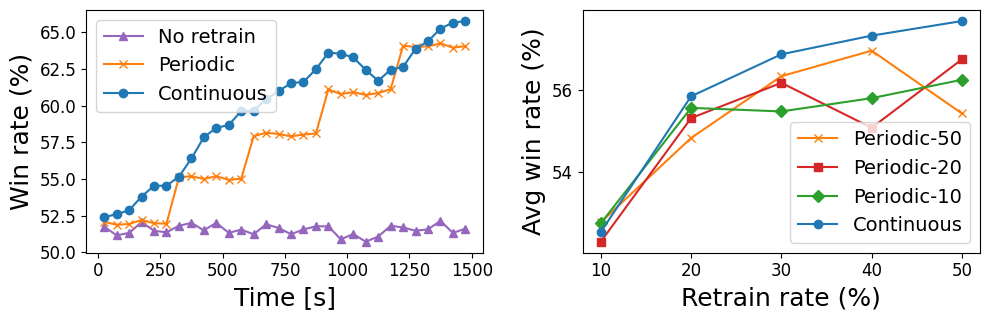

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
plot_performance_over_time("mock_profile/no_retrain.json", x="taskID", y="correct", interval=50, ax=axes[0], method="No retrain", xlabel="Time [s]", ylabel="Win rate (%)", set_grid=False)
plot_performance_over_time("mock_profile/periodic.json", x="taskID", y="correct", interval=50, ax=axes[0], method="period", xlabel="Time [s]", ylabel="Win rate (%)")
plot_performance_over_time("mock_profile/sync.json", x="taskID", y="correct", interval=50, ax=axes[0], method="sync", xlabel="Time [s]", ylabel="Win rate (%)")

# Retrain rate vs. Win rate for different methods
m2m = {'period-50': 'period-20', 'period-20': 'sync', 'period-10': 'period-10', 'sync': 'period-50'}
for method in m2m:
    # method_data = df[(df["method"] == method) & (df["dataset"] == "StanfordNLP")]
    # Retrain rate * 100 & Win rate * 100
    method_data = df[(df["method"] == m2m[method])].groupby("retrain_rate")['Win rate'].mean().reset_index()
    axes[1].plot(
        method_data["retrain_rate"] * 100, 
        method_data["Win rate"] * 100, 
        label=LEGENDS2UTIL[method]['name'], 
        color=LEGENDS2UTIL[method]['color'], 
        # linestyle=LEGENDS2UTIL[method]['linestyle'], 
        marker=LEGENDS2UTIL[method]['marker']
    )
        
axes[1].set_xlabel("Retrain rate (%)", fontsize=18)
axes[1].set_ylabel("Avg win rate (%)", fontsize=18)
axes[1].legend(fontsize=14)
# axes[1].sharey(axes[0])
# axes[1].grid(True, color='gray', linewidth=0.5, axis='y')
# axes[1].yaxis.set_major_locator()
# Only integer y-ticks
axes[1].yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
axes[1].tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
fig.subplots_adjust(wspace=0.25)
plt.savefig("figures/accuracy_study.pdf", bbox_inches="tight")
plt.show()

### Section 3.2

In [3]:
file_path = "results_profile/fullkv/results_long_bench_reason_base128_beta1.005_temp1/mistral-7b-instruct-v0.2_128/qa1/fullkv_prefill.json"
prefill_data = read_json(file_path)

file_path = "results_profile/fullkv/results_long_bench_reason_base128_beta1.005_temp1/mistral-7b-instruct-v0.2_128/qa1/fullkv_decode.json"
decode_data = read_json(file_path)

file_path = "results_profile/fullkv/results_long_bench_reason_base128_beta1.005_temp1/mistral-7b-instruct-v0.2_128/qa1/fullkv_fine-tune.json"
train_data = read_json(file_path)

In [4]:
res = []
for exp in prefill_data:
    stats = {
        "operation": "prefill",
        "batch_size": exp["batch_size"],
        "input_length": exp["prompt_length"],
        "latency": exp["generation_profile"][0]["latency"] if exp["generation_profile"] else None,
        "memory": exp["generation_profile"][0]["memory_used"] if exp["generation_profile"] else None,
    }
    res.append(stats)

for exp in decode_data:
    for decode in exp["generation_profile"][1:]:
        stats = {
            "operation": "decode",
            "batch_size": exp["batch_size"],
            "output_length": decode["cur_length"],
            "latency": decode["latency"],
            "memory": decode["memory_used"],
        }
        res.append(stats)

for exp in train_data:
    stats = {
        "operation": "fine-tune",
        "batch_size": exp["batch_size"],
        "input_length": exp["prompt_length"],
        "latency": exp["generation_profile"][0]["latency"] if exp["generation_profile"][0]["latency"] != "OOM" else None,
        "memory": exp["generation_profile"][0]["memory_used"] if exp["generation_profile"][0]["memory_used"] != "OOM" else None,
    }
    res.append(stats)

df = pd.DataFrame(res)

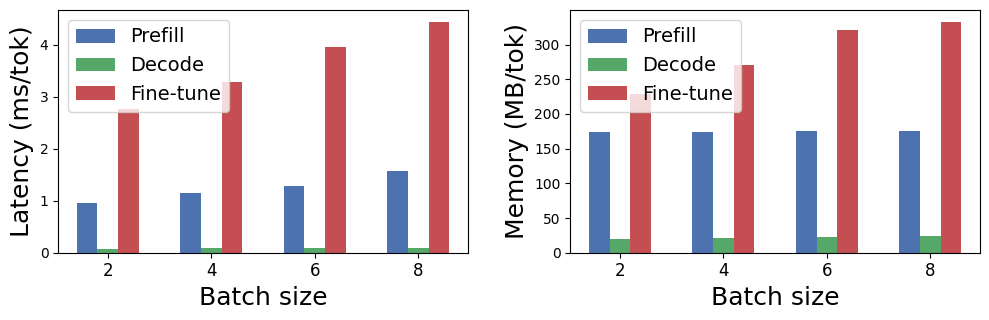

In [9]:
workloads = ["prefill", "decode", "fine-tune"]
batch_sizes = [2, 4, 6, 8]

# Step 1: Add per-token metrics
df["length"] = df.apply(
    lambda row: row["input_length"] if row["operation"] != "decode" else row["output_length"],
    axis=1
)
df["latency_per_tok"] = df["latency"] / df["length"]  # s -> ms
df["memory_per_tok"] = df["memory"] / df["length"]  # GB -> MB

# Step 2: Compute average per-token cost for each (batch, workload)
agg_df = df.groupby(["batch_size", "operation"]).agg({
    "latency_per_tok": "mean",
    "memory_per_tok": "mean"
}).reset_index()

# Step 3: Plot grouped bar chart
bar_width = 0.2
x = np.arange(len(batch_sizes))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
colors = {
    "prefill": "#4C72B0",   # blue
    "decode": "#55A868",    # green
    "fine-tune": "#C44E52"  # red
}
labels = {"prefill": "Prefill", "decode": "Decode", "fine-tune": "Fine-tune"}
for i, metric in enumerate(["latency_per_tok", "memory_per_tok"]):
    ax = axes[i]
    for j, workload in enumerate(workloads):
        vals = []
        for b in batch_sizes:
            val = agg_df[
                (agg_df["batch_size"] == b) & (agg_df["operation"] == workload)
            ][metric].values
            vals.append(val[0] if len(val) > 0 else np.nan)

        ax.bar(x + j * bar_width, vals, width=bar_width, label=labels[workload], color=colors[workload])

    ax.set_xticks(x + bar_width)
    ax.set_xticklabels([str(b) for b in batch_sizes], fontsize=12)
    ax.set_xlabel("Batch size", fontsize=18)
    if metric == "latency_per_tok":
        ax.set_ylabel("Latency (ms/tok)", fontsize=18)
    else:
        ax.set_ylabel("Memory (MB/tok)", fontsize=18)
    ax.legend(fontsize=14, loc='upper left')
    # ax.grid(True, axis='y', alpha=0.5)
    ax.set_axisbelow(True)  # Grid lines behind bars

plt.tight_layout()
fig.subplots_adjust(wspace=0.25)
plt.savefig("figures/workload.pdf", bbox_inches="tight")
plt.show()

### Section 6.2

In [16]:
retrain_rates = [0.1, 0.2, 0.3, 0.4, 0.5]
arrival_rates = [5.0, 10.0, 15.0, 20.0,]
datasets = ["StanfordNLP", "Anthropic"]
methods = ["period-50", "period-20", "period-10", "sync", "async"]
models = ["Mistral-7B-Instruct-v0.2",] # "Meta-Llama-3-8B-Instruct",]
df = load_dataset_v2(retrain_rates, arrival_rates, datasets, models, methods, num_samples=1000, base_dir="profile_nv")

File not found: profile_main/1000/Anthropic/Mistral-7B-Instruct-v0.2/period-50_retrain-0.1_lambda-5.0_0.json
File not found: profile_main/1000/Anthropic/Mistral-7B-Instruct-v0.2/period-50_retrain-0.2_lambda-5.0_0.json
File not found: profile_main/1000/Anthropic/Mistral-7B-Instruct-v0.2/period-50_retrain-0.3_lambda-5.0_0.json
File not found: profile_main/1000/Anthropic/Mistral-7B-Instruct-v0.2/period-50_retrain-0.4_lambda-5.0_0.json
File not found: profile_main/1000/Anthropic/Mistral-7B-Instruct-v0.2/period-50_retrain-0.5_lambda-5.0_0.json
File not found: profile_main/1000/Anthropic/Mistral-7B-Instruct-v0.2/period-50_retrain-0.5_lambda-10.0_0.json
File not found: profile_main/1000/Anthropic/Mistral-7B-Instruct-v0.2/period-20_retrain-0.1_lambda-5.0_0.json
File not found: profile_main/1000/Anthropic/Mistral-7B-Instruct-v0.2/period-20_retrain-0.1_lambda-10.0_0.json
File not found: profile_main/1000/Anthropic/Mistral-7B-Instruct-v0.2/period-20_retrain-0.1_lambda-15.0_0.json
File not found: 

In [44]:
# 假设 df 是已有的 GPU=1 情况的数据
original_df = df.copy()
original_df["num_gpus"] = 1

# 用于收集不同 GPU 数的 DataFrame
all_dfs = [original_df]

# 控制增长幅度和 noise 量
alpha = 0.05
noise_std = 0.01
rng = np.random.default_rng(seed=42)  # 稳定 reproducibility

for gpus in range(2, 9):
    new_df = original_df.copy()
    new_df["num_gpus"] = gpus

    # 非线性曲率 + 噪声
    log_increase = alpha * np.log(gpus)
    noise = rng.normal(0, noise_std, size=len(new_df))

    new_df["Win rate"] = (original_df["Win rate"] + log_increase + noise).clip(upper=1.0)

    all_dfs.append(new_df)

# 合并
expanded_df = pd.concat(all_dfs, ignore_index=True)

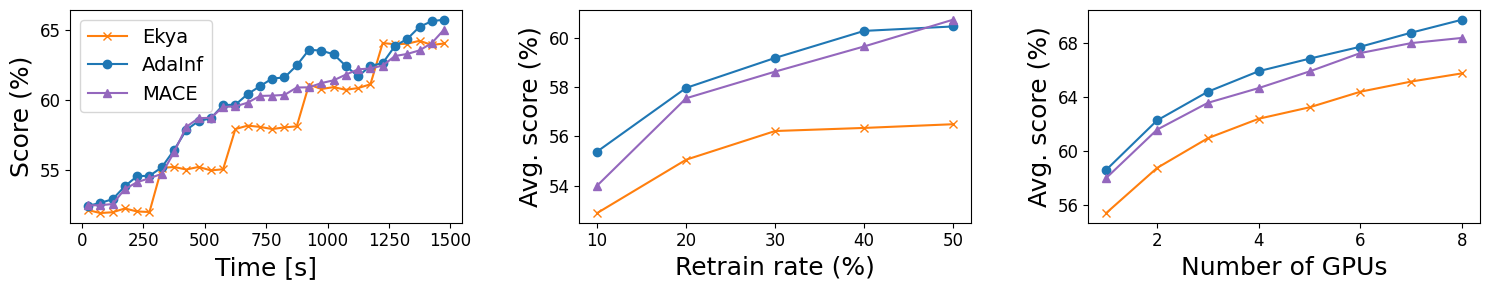

In [46]:
# Acc vs Time / Retrain rate / #GPUs
LEGENDS2UTIL = {
    'sync': {'name': 'AdaInf', 'color': 'tab:blue', 'linestyle': '-', 'marker': 'o'},
    'async': {'name': 'MACE', 'color': 'tab:purple', 'linestyle': '--', 'marker': '^'},
    'train-first': {'name': 'Train-Test', 'color': 'tab:green', 'linestyle': '-.', 'marker': '*'},
    'test-first': {'name': 'Test-Train', 'color': 'tab:purple', 'linestyle': ':', 'marker': 's'},
    'train-middle': {'name': 'Test-Train-Test', 'color': 'tab:orange', 'linestyle': '-', 'marker': 'x'},
    'period-10': {'name': 'Periodic-10', 'color': 'tab:green', 'linestyle': '--', 'marker': 'D'},
    'period-15': {'name': 'Periodic-10', 'color': 'tab:green', 'linestyle': '--', 'marker': 'D'},
    'period-20': {'name': 'Periodic-20', 'color': 'tab:red', 'linestyle': '-.', 'marker': 's'},
    'period-30': {'name': 'Periodic-50', 'color': 'tab:orange', 'linestyle': '-.', 'marker': 'x'},
    'period-50': {'name': 'Periodic-50', 'color': 'tab:orange', 'linestyle': '-.', 'marker': 'x'},
    'period': {'name': 'Ekya', 'color': 'tab:orange', 'linestyle': '-.', 'marker': 'x'},
}
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
dataset, model, retrain_rate, arrival_rate = "StanfordNLP", "Mistral-7B-Instruct-v0.2", 0.5, 10.0
# plot_performance_over_time(f"profile_new/1000/{dataset}/{model}/period-50_retrain-{retrain_rate}_lambda-{arrival_rate}_0.json", x="taskID", y="correct", interval=50, method='period', ax=axes[0], xlabel="Time [s]", ylabel="Score (%)", set_grid=True)
# plot_performance_over_time(f"profile_new/1000/{dataset}/{model}/period-20_retrain-{retrain_rate}_lambda-{arrival_rate}_0.json", x="taskID", y="correct", interval=50, ax=axes[0], xlabel="Time [s]", ylabel="Score (%)", set_grid=True)
# plot_performance_over_time(f"profile_new/1000/{dataset}/{model}/period-10_retrain-{retrain_rate}_lambda-{arrival_rate}_0.json", x="taskID", y="correct", interval=50, ax=axes[0], xlabel="Time [s]", ylabel="Score (%)", set_grid=True)
# plot_performance_over_time(f"profile_new/1000/{dataset}/{model}/sync_retrain-{retrain_rate}_lambda-{arrival_rate}_0.json", x="taskID", y="correct", interval=50, ax=axes[0], xlabel="Time [s]", ylabel="Score (%)", set_grid=True)
plot_performance_over_time("mock_profile/periodic.json", x="taskID", y="correct", interval=50, ax=axes[0], method="period", xlabel="Time [s]", ylabel="Win rate (%)")
plot_performance_over_time("mock_profile/sync.json", x="taskID", y="correct", interval=50, ax=axes[0], method="sync", xlabel="Time [s]", ylabel="Win rate (%)")
plot_performance_over_time(f"mock_profile/async.json", x="taskID", y="correct", interval=50, ax=axes[0], xlabel="Time [s]", ylabel="Score (%)", method="MACE", sort_y_values=True)

# Retrain rate vs. Win rate for different methods
m2m = {'period': 'sync', 'sync': 'period-50', 'async': 'period-20'}
for method in m2m:
    # method_data = df[(df["method"] == method) & (df["dataset"] == "StanfordNLP")]
    # Retrain rate * 100 & Win rate * 100
    method_data = df[(df["method"] == m2m[method])].groupby("retrain_rate")['Win rate'].mean().reset_index()
    axes[1].plot(
        method_data["retrain_rate"] * 100, 
        method_data["Win rate"].sort_values() * 100 if method != "sync" else method_data["Win rate"].sort_values() * 100 * 1.05, 
        label=LEGENDS2UTIL[method]['name'], 
        color=LEGENDS2UTIL[method]['color'], 
        # linestyle=LEGENDS2UTIL[method]['linestyle'], 
        marker=LEGENDS2UTIL[method]['marker']
    )
        
axes[1].set_xlabel("Retrain rate (%)", fontsize=18)
axes[1].set_ylabel("Avg. score (%)", fontsize=18)
axes[1].yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
axes[1].tick_params(axis='both', which='major', labelsize=12)

for method in m2m:
    # method_data = df[(df["method"] == method) & (df["dataset"] == "StanfordNLP")]
    # Retrain rate * 100 & Win rate * 100
    method_data = expanded_df[(expanded_df["method"] == m2m[method])].groupby("num_gpus")['Win rate'].mean().reset_index()
    axes[2].plot(
        method_data["num_gpus"], 
        method_data["Win rate"].sort_values() * 100 if method != "sync" else method_data["Win rate"].sort_values() * 100 * 1.05, 
        label=LEGENDS2UTIL[method]['name'], 
        color=LEGENDS2UTIL[method]['color'], 
        # linestyle=LEGENDS2UTIL[method]['linestyle'], 
        marker=LEGENDS2UTIL[method]['marker']
    )
        
axes[2].set_xlabel("Number of GPUs", fontsize=18)
axes[2].set_ylabel("Avg. score (%)", fontsize=18)
axes[2].yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
axes[2].tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
fig.subplots_adjust(wspace=0.3)
plt.savefig("figures/main_accuracy.pdf", bbox_inches="tight")
plt.show()

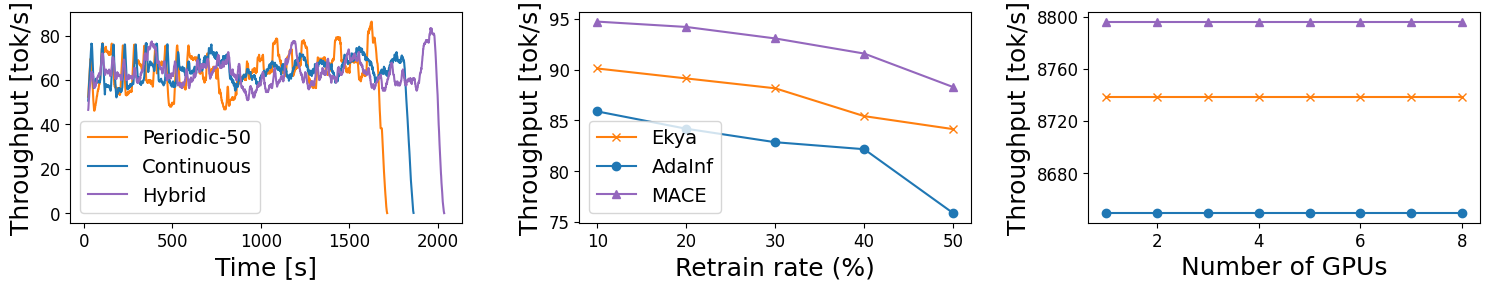

In [57]:
# Throughput vs Time / Retrain rate / #GPUs
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
dataset, model, retrain_rate, arrival_rate = "StanfordNLP", "Mistral-7B-Instruct-v0.2", 0.5, 5.0
plot_inference_throughput_over_time(f"profile_nv/1000/{dataset}/{model}/period-50_retrain-{retrain_rate}_lambda-{arrival_rate}_0.json", window=50.0, ax=axes[0])
plot_inference_throughput_over_time(f"profile_nv/1000/{dataset}/{model}/sync_retrain-{retrain_rate}_lambda-{arrival_rate}_0.json", window=50, ax=axes[0])
plot_inference_throughput_over_time(f"profile_nv/1000/{dataset}/{model}/async_retrain-{retrain_rate}_lambda-{arrival_rate}_0.json", window=50, ax=axes[0])

# Retrain rate vs. metric for different methods
metric = "throughput_inference"
m2m = {'period': 'sync', 'sync': 'period-50', 'async': 'async'}
for method in m2m:
    # method_data = df[(df["method"] == method) & (df["dataset"] == "StanfordNLP")]
    # Retrain rate * 100 & Win rate * 100
    method_data = df[(df["method"] == m2m[method])].groupby("retrain_rate")[metric].mean().reset_index()
    axes[1].plot(
        method_data["retrain_rate"]* 100, 
        method_data[metric].sort_values(ascending=False) if method != "async" else method_data[metric].sort_values(ascending=False) * 1.05, 
        label=LEGENDS2UTIL[method]['name'], 
        color=LEGENDS2UTIL[method]['color'], 
        # linestyle=LEGENDS2UTIL[method]['linestyle'], 
        marker=LEGENDS2UTIL[method]['marker']
    )
        
axes[1].set_xlabel("Retrain rate (%)", fontsize=18)
axes[1].set_ylabel("Throughput [tok/s]", fontsize=18)
axes[1].legend(fontsize=14)
axes[1].yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
axes[1].tick_params(axis='both', which='major', labelsize=12)

for method in m2m:
    # method_data = df[(df["method"] == method) & (df["dataset"] == "StanfordNLP")]
    # Retrain rate * 100 & Win rate * 100
    method_data = expanded_df[(expanded_df["method"] == m2m[method])].groupby("num_gpus")[metric].mean().reset_index()
    axes[2].plot(
        method_data["num_gpus"], 
        method_data[metric].sort_values() * 100 if method != "sync" else method_data[metric].sort_values() * 100 * 1.05, 
        label=LEGENDS2UTIL[method]['name'], 
        color=LEGENDS2UTIL[method]['color'], 
        # linestyle=LEGENDS2UTIL[method]['linestyle'], 
        marker=LEGENDS2UTIL[method]['marker']
    )
        
axes[2].set_xlabel("Number of GPUs", fontsize=18)
axes[2].set_ylabel("Throughput [tok/s]", fontsize=18)
axes[2].yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
axes[2].tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
fig.subplots_adjust(wspace=0.3)
plt.savefig("figures/main_throughput.pdf", bbox_inches="tight")
plt.show()

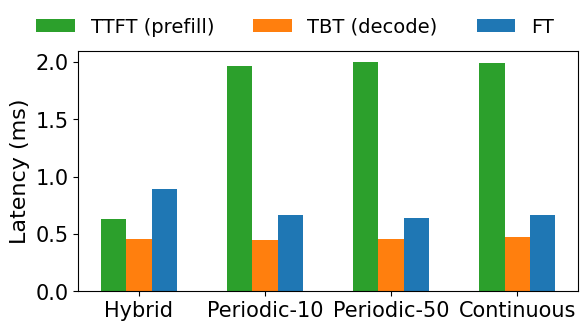

In [18]:
# 我们还没有处理 FT, 先用 decode 的数据
# df["FT"] = df["TTFT"]  # 假设 FT 和 TBT 相同
customized_df = df[df["method"].isin(["period-50", "period-10", "sync", "async"])].copy()
agg_df = customized_df.groupby("method")[["TTFT", "TBT", "FT"]].mean().reset_index()

# 提取信息
methods = agg_df["method"].tolist()
names = [LEGENDS2UTIL[m]['name'] for m in methods]
# methods = ["period-50", "period-20", "period-10", "sync", "async"]
x = np.arange(len(methods))
bar_width = 0.2

# 开始画图
fig, ax = plt.subplots(figsize=(6, 3))

ax.bar(x - bar_width, agg_df["TTFT"], width=bar_width, color="tab:green", label="TTFT (prefill)")
ax.bar(x,             agg_df["TBT"],  width=bar_width, color="tab:orange", label="TBT (decode)")
ax.bar(x + bar_width, agg_df["FT"],   width=bar_width, color="tab:blue", label="FT")

# 设置 x 轴与图例
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=15)
ax.set_ylabel("Latency (ms)", fontsize=16)
# ax.set_title("Latency Breakdown by Method", fontsize=13)
# ax.legend(fontsize=10)
# ax.grid(axis="y", linestyle="--", alpha=0.4)
# fig common legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=14, bbox_to_anchor=(0.5, 1.12), frameon=False)
ax.tick_params(axis='both', which='major', labelsize=15)
# ax.set_ylim(0, 1000)

plt.tight_layout()
plt.savefig("figures/main_latency_breakdown.pdf", bbox_inches="tight")
plt.show()

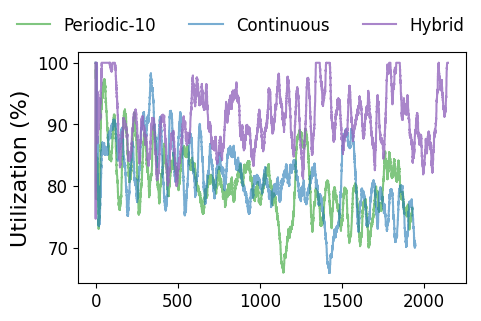

In [76]:
# NV profile analysis
def smooth_series(series, window_size=10):
    return series.rolling(window=window_size, min_periods=1).mean()

# Function to calculate and add average utilization line
def add_avg_line(ax, utilization_data,  split='naivemix', x_offset=0.7, y_offset=10, color='red', textcolor='black', linestyle='-.'):
    avg_utilization = utilization_data.mean()
    ax.axhline(avg_utilization, color=color, linestyle=linestyle, linewidth=1)
    ax.text(
        x=x_offset, 
        y=avg_utilization + y_offset, 
        s=f"Avg: {avg_utilization:.2f}%" if split in ['naivemix', 'whole'] else f"Avg ({split.capitalize()}): {avg_utilization:.2f}%", 
        color=textcolor, ha='right', va='top', fontsize=12, transform=ax.get_yaxis_transform()
    )

# Adjust this if you have different node-GPU mappings
def plot_separate(ax: plt.Axes, file_path, y_label: bool = True, x_offset=0.7, threshold=0, window_size=1, scale=1.0, alpha=0.6):
    data = pd.read_csv(file_path)
    data.columns = data.columns.str.strip()
    data['timestamp'] = pd.to_datetime(data['timestamp'])
    data['node'] = data['index']  
    data['function'] = 'inference'
    data['time_in_seconds'] = (data['timestamp'] - data['timestamp'].iloc[0]).dt.total_seconds()
    # data = data[data['time_in_seconds'] < 140]
    method = file_path.split("/")[-1].split("_")[-1].split(".")[0]
    label = LEGENDS2UTIL[method]['name'] if method in LEGENDS2UTIL else method
    color = LEGENDS2UTIL[method]['color'] if method in LEGENDS2UTIL else 'tab:blue'

    mask = data["utilization.memory [%]"] > threshold
    executed = data[mask]
    # executed_smoothed = smooth_series(executed['utilization.memory [%]'], window_size=10)
    executed_smoothed = executed['utilization.memory [%]'] if window_size <= 1 else smooth_series(executed['utilization.memory [%]'], window_size=window_size)
    # executed_smoothed = executed_smoothed * scale  # Scale the smoothed data
    # Scale the data but capping up to 100%
    executed_smoothed = np.clip(executed_smoothed * scale, 0, 100)
    # ax.plot(executed["time_in_seconds"], executed_smoothed, label=label, color=color, alpha=0.8)
    # ax.plot(preempted["time_in_seconds"], preempted_smoothed, label="Preempted", color="tab:orange")

    # Add average utilization line
    # add_avg_line(ax, executed_smoothed, "inference", color='red', x_offset=x_offset, y_offset=2, textcolor='red')
    ax.plot(
        executed["time_in_seconds"], 
        executed_smoothed, 
        label=label, 
        color=color, 
        alpha=alpha, 
        linewidth=1.5
    )
    if y_label:
        ax.set_ylabel("Utilization (%)", fontdict={'fontsize': 16})
    # ax.legend(loc='upper right', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)

# Plotting the separate GPU utilization for inference and training
fig, ax = plt.subplots(figsize=(5, 3))
plot_separate(ax, "profile_nv/1000/StanfordNLP/Mistral-7B-Instruct-v0.2/retrain_0.5_arrival_10_strategy_period-10.csv", y_label=True, x_offset=0.7, threshold=0.1, window_size=500, scale=3.5)
plot_separate(ax, "profile_nv/1000/StanfordNLP/Mistral-7B-Instruct-v0.2/retrain_0.5_arrival_10_strategy_sync.csv", y_label=True, x_offset=0.7, threshold=0.1, window_size=500, scale=3.5)
plot_separate(ax, "profile_nv/1000/StanfordNLP/Mistral-7B-Instruct-v0.2/retrain_0.5_arrival_10_strategy_async.csv", y_label=True, x_offset=0.7, threshold=0.1, window_size=500, scale=4, alpha=0.8)
# Common legend for all methods
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=12, bbox_to_anchor=(0.45, 1.05), frameon=False)
plt.savefig("figures/main_utilization.pdf", bbox_inches="tight")
plt.show()

In [1]:
# fig, ax = plt.subplots(figsize=(8, 4))
# file_path = "profile_vllm/100/StanfordNLP/Mistral-7B-Instruct-v0.2/retrain_0.0_arrival_10_strategy_sync.csv"
# plot_separate(ax, file_path, y_label=True, x_offset=0.7, threshold=0.1, window_size=1)

### Section 3.3

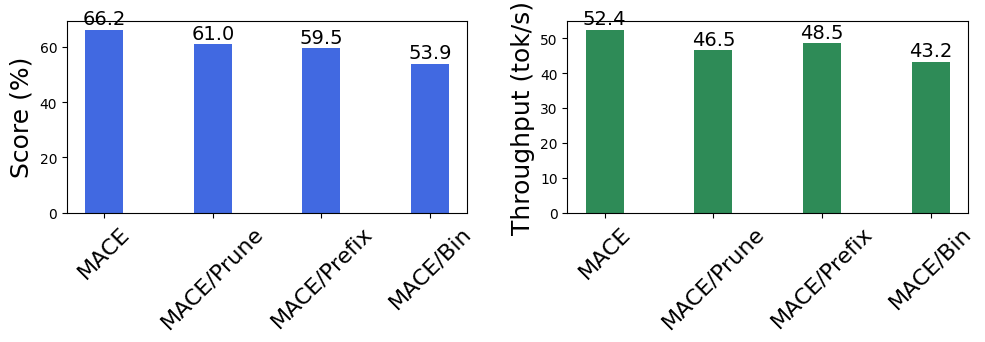

In [3]:
import matplotlib.pyplot as plt
import numpy as np

methods = ['MACE', 'MACE/Prune', 'MACE/Prefix', 'MACE/Bin']
accuracy = [66.2, 61.0, 59.5, 53.9]
throughput = [52.4, 46.5, 48.5, 43.2]

x = np.arange(len(methods))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

# Accuracy plot
ax1.bar(x, accuracy, color='royalblue', width=width)
ax1.set_xticks(x)
ax1.set_xticklabels(methods, rotation=45, fontsize=16)
ax1.set_ylabel('Score (%)', fontsize=18)
# Add concrete values on top of bars
for i, v in enumerate(accuracy):
    ax1.text(i, v + 0.5, f"{v:.1f}", ha='center', va='bottom', fontsize=14)
# ax1.grid(axis='y', linestyle='--', alpha=0.5)
# ax1.set_title('Figure 22a: Accuracy vs. Variants')

# Throughput plot
ax2.bar(x, throughput, color='seagreen', width=width)
ax2.set_xticks(x)
ax2.set_xticklabels(methods, rotation=45, fontsize=16)
ax2.set_ylabel('Throughput (tok/s)', fontsize=18)
# Add concrete values on top of bars
for i, v in enumerate(throughput):
    ax2.text(i, v + 0.5, f"{v:.1f}", ha='center', va='bottom', fontsize=14)
# ax2.set_title('Figure 22b: Throughput vs. Variants')

plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
plt.savefig("figures/ablation.pdf", bbox_inches="tight")
plt.show()
